In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r'C:\Users\USER\Desktop\customer-churn-analysis\cleaned_ecommerce_churn_dataset.csv')

In [4]:
import matplotlib.pyplot as plt

In [5]:
import numpy as np

In [6]:
import matplotlib.ticker as mticker

In [7]:
import seaborn as sns

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
from scipy import stats

In [10]:
df.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,...,category,gender,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactive_ratio
0,ORD5000,CUST1000,39,PROD200,Canada,2021-01-07,2023-02-21,0,active,2024-08-20,...,Sports,Female,391.05,912,37,391.05,1687,10.568919,0.021932,0.540605
1,ORD5001,CUST1001,61,PROD201,USA,2020-10-19,2021-12-08,0,active,2025-07-17,...,Home,Female,512.16,1352,35,512.16,1767,14.633143,0.019808,0.765139
2,ORD5002,CUST1002,26,PROD202,Pakistan,2023-06-10,2023-09-04,3,cancelled,2025-03-12,...,Clothing,Female,1208.28,717,44,1208.28,803,27.460909,0.054795,0.892902
3,ORD5003,CUST1003,54,PROD203,India,2023-07-30,2024-02-20,4,paused,2024-09-19,...,Beauty,Male,338.64,548,1,338.64,753,338.640000,0.001328,0.727756
4,ORD5004,CUST1004,50,PROD204,India,2020-12-09,2024-09-14,0,active,2024-08-08,...,Electronics,Male,438.62,341,35,438.62,1716,12.532000,0.020396,0.198718


In [11]:
df.describe().round(2)

,age,cancellations_count,unit_price,quantity,order_amount,recency_days,frequency,monetary,tenure_days,avg_order_value,purchase_intensity,inactive_ratio
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,44.08,2.44,324.72,4.95,1025.85,631.22,25.16,1025.85,1286.95,89.45,0.02,0.49
std,14.80,1.70,361.55,2.56,560.79,410.96,14.16,560.79,313.31,178.78,0.01,0.29
min,18.00,0.00,2.85,1.00,22.29,1.00,1.00,22.29,732.00,0.48,0.00,0.00
25%,31.00,1.00,111.13,3.00,551.94,285.00,13.00,551.94,1017.00,21.47,0.01,0.24
50%,45.00,2.00,206.52,5.00,1057.23,586.00,25.00,1057.23,1300.00,40.04,0.02,0.48
75%,57.00,4.00,384.51,7.00,1494.68,907.00,37.00,1494.68,1558.25,81.68,0.03,0.74
max,69.00,5.00,1991.63,9.00,1998.08,1796.00,49.00,1998.08,1827.00,1994.70,0.07,1.00


In [12]:
df.isnull().sum()

order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
preferred_category     0
product_name           0
category               0
gender                 0
order_amount           0
recency_days           0
frequency              0
monetary               0
tenure_days            0
avg_order_value        0
purchase_intensity     0
inactive_ratio         0
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2000 non-null   str    
 1   customer_id          2000 non-null   str    
 2   age                  2000 non-null   int64  
 3   product_id           2000 non-null   str    
 4   country              2000 non-null   str    
 5   signup_date          2000 non-null   str    
 6   last_purchase_date   2000 non-null   str    
 7   cancellations_count  2000 non-null   int64  
 8   subscription_status  2000 non-null   str    
 9   order_date           2000 non-null   str    
 10  unit_price           2000 non-null   float64
 11  quantity             2000 non-null   int64  
 12  preferred_category   2000 non-null   str    
 13  product_name         2000 non-null   str    
 14  category             2000 non-null   str    
 15  gender               2000 non-null   str    
 16 

In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

3. Target Variable Definition

The dataset has no explicit Churn binary column. We derive it from subscription_status:

subscription_status	Label	Rationale
active	Active (0)	Currently engaged customer
cancelled	Churned (1)	Hard churn — subscription ended
paused	Paused (at-risk)	Soft churn — noted separately, not included in binary target
Decision: Churn = 1 if subscription_status == 'cancelled' (hard churn). It is clearer for modeling. Paused customers are tracked separately as an at-risk group. (soft churn)

In [15]:
df['churn'] = (df['subscription_status'] == 'cancelled').astype('int') 
status__map = {'cancelled':'churn','active':'Active','paused':'Paused'}

df['churn_label'] = df['subscription_status'].map(status__map)


In [16]:
df['churn_label'].value_counts()

churn_label
Active    1204
churn      493
Paused     303
Name: count, dtype: int64

In [17]:
Active_counts = (df['churn_label'] == 'Active').sum()

Active_pct = Active_counts*100/len(df)

print(f'\nActive customer: {Active_pct}%')



Active customer: 60.2%


In [18]:
df['churn_label'] = df['subscription_status'].map(status__map)

In [19]:
df.columns

Index(['order_id', 'customer_id', 'age', 'product_id', 'country',
       'signup_date', 'last_purchase_date', 'cancellations_count',
       'subscription_status', 'order_date', 'unit_price', 'quantity',
       'preferred_category', 'product_name', 'category', 'gender',
       'order_amount', 'recency_days', 'frequency', 'monetary', 'tenure_days',
       'avg_order_value', 'purchase_intensity', 'inactive_ratio', 'churn',
       'churn_label'],
      dtype='str')

In [20]:
counts = df['churn_label'].value_counts()
for status,n in counts.items():
    print(f"{status:<12} {n:>5} ({n/len(df)*100:.1f}%)")

print(f'\nBinary churn rate (cancelled only): {df["churn"].mean()*100:.1f}%')
print(f"  churned : {df['churn'].sum():,}")
print(f'  Active  (0): {(df["churn"]==0).sum():,}  (includes {(df["subscription_status"]=="paused").sum()} paused)')
     

Active        1204 (60.2%)
churn          493 (24.6%)
Paused         303 (15.2%)

Binary churn rate (cancelled only): 24.6%
  churned : 493
  Active  (0): 1,507  (includes 303 paused)


In [21]:
# Create binary target variable
df['target'] = (df['subscription_status'] == 'churn').astype(int)

# Verify
print(df['target'].value_counts())
print(f"\nChurn Rate: {df['target'].mean()*100:.1f}%")

target
0    2000
Name: count, dtype: int64

Churn Rate: 0.0%


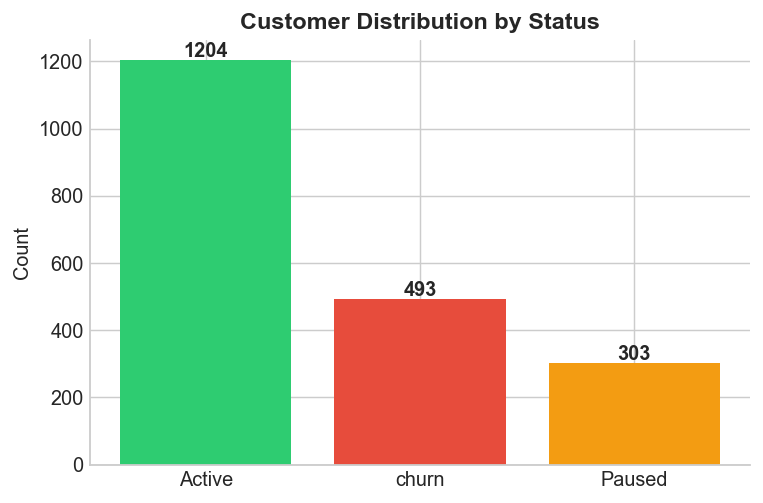

In [22]:
fis, ax = plt.subplots(figsize=(6,4))
counts = df['churn_label'].value_counts()
colors = ['#2ecc71','#e74c3c','#f39c12']
ax.bar(counts.index, counts.values,color=colors)
ax.set_title('Customer Distribution by Status')
ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v+10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/churn_distribution.png', dpi=150)
plt.show()

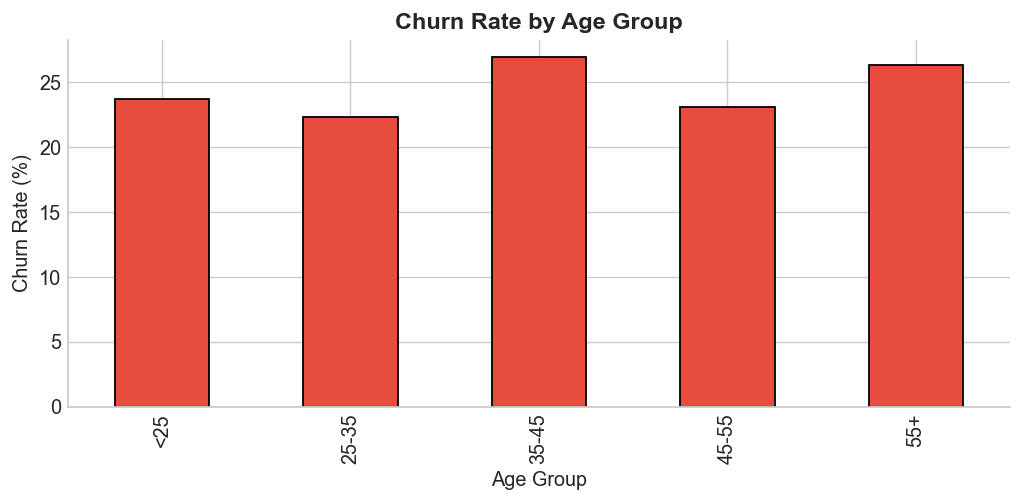

In [23]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,100],
                          labels=['<25','25-35','35-45','45-55','55+'])
churn_age = df.groupby('age_group')['churn'].mean()*100

fig, ax = plt.subplots(figsize=(8,4))
churn_age.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('Churn Rate by Age Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Age Group')
plt.tight_layout()
plt.savefig('charts/churn_by_age.png', dpi=150)
plt.show()

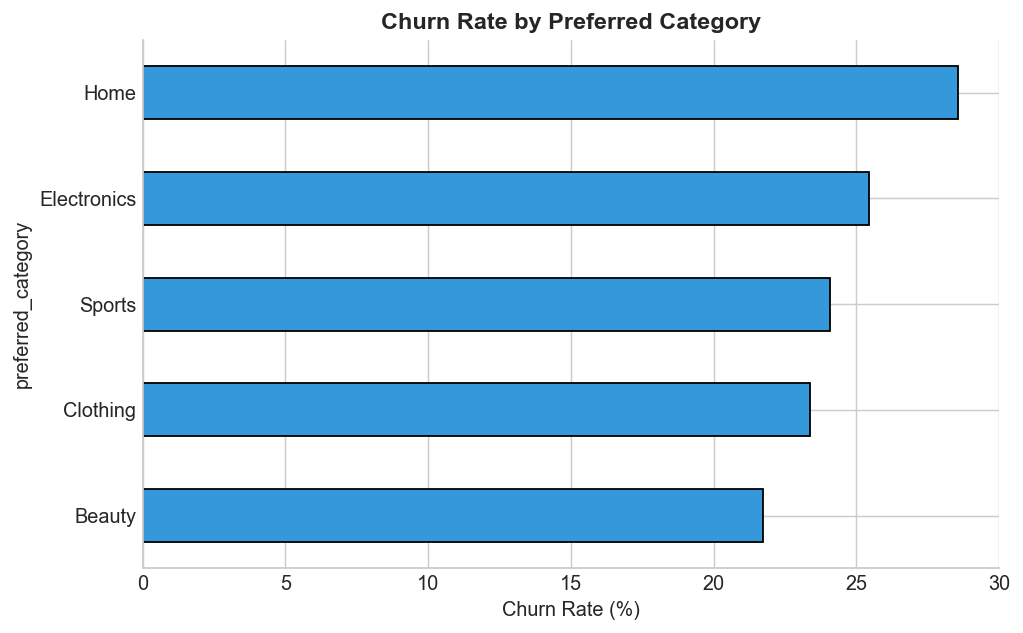

In [24]:
churn_cat = df.groupby('preferred_category')['churn'].mean()*100
churn_cat = churn_cat.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8,5))
churn_cat.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Churn Rate by Preferred Category')
ax.set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('charts/churn_by_category.png', dpi=150)
plt.show()

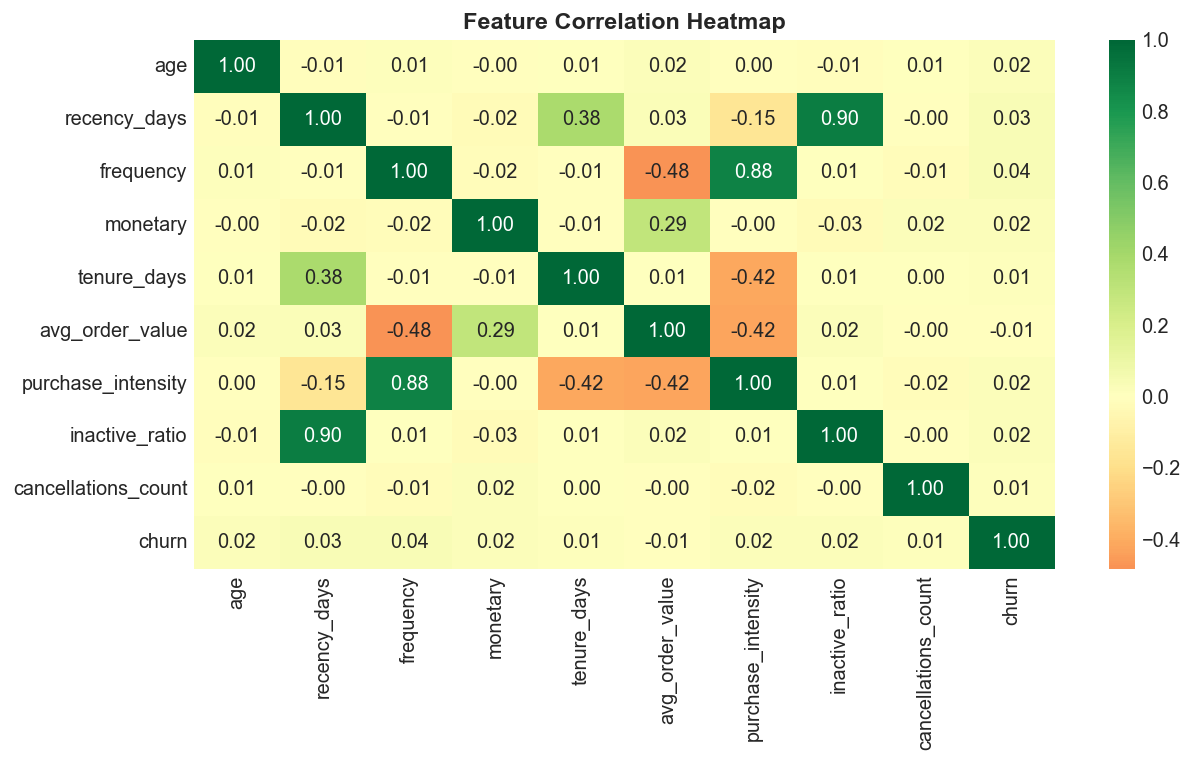

In [25]:
fig, ax = plt.subplots(figsize=(10,6))

num_cols = ['age','recency_days','frequency','monetary',
            'tenure_days','avg_order_value','purchase_intensity',
            'inactive_ratio','cancellations_count','churn']

corr = df[num_cols].corr()

sns.heatmap(corr,annot=True, fmt='.2f', cmap='RdYlGn',center=0, ax=ax)

ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150)
plt.show()

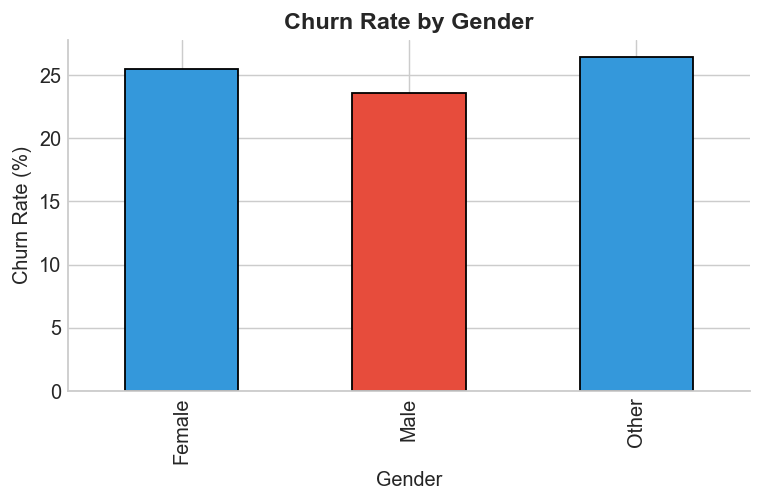

In [26]:
fig, ax = plt.subplots(figsize=(6,4))
gender_churn = df.groupby('gender')['churn'].mean()*100
gender_churn.plot(kind='bar', ax=ax, color=['#3498db','#e74c3c'],
                  edgecolor='black')
ax.set_title('Churn Rate by Gender')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Gender')
plt.tight_layout()
plt.savefig('charts/churn_by_gender.png', dpi=150)
plt.show()

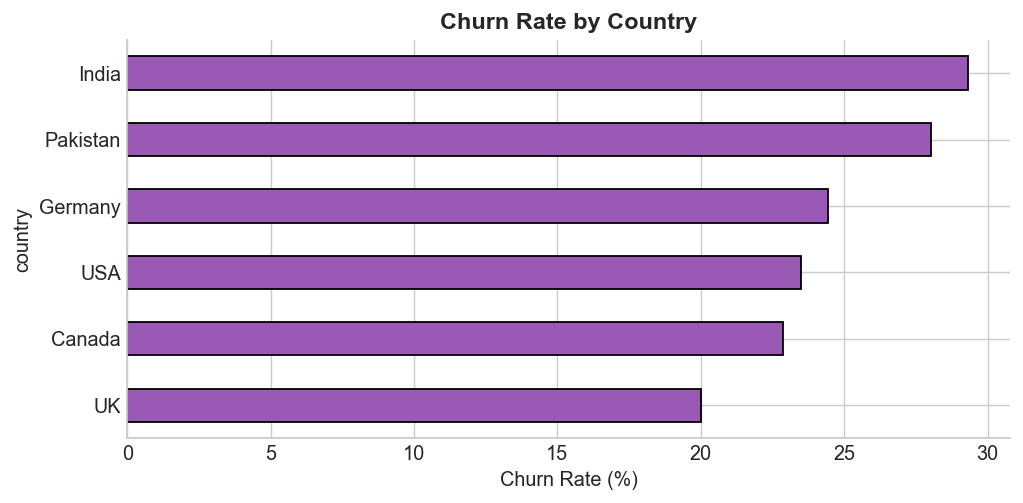

In [27]:
fig, ax = plt.subplots(figsize=(8,4))
country_churn = df.groupby('country')['churn'].mean()*100
country_churn.sort_values(ascending=True).plot(
    kind='barh', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('Churn Rate by Country')
ax.set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('charts/churn_by_country.png', dpi=150)
plt.show()

In [29]:
df.columns

Index(['order_id', 'customer_id', 'age', 'product_id', 'country',
       'signup_date', 'last_purchase_date', 'cancellations_count',
       'subscription_status', 'order_date', 'unit_price', 'quantity',
       'preferred_category', 'product_name', 'category', 'gender',
       'order_amount', 'recency_days', 'frequency', 'monetary', 'tenure_days',
       'avg_order_value', 'purchase_intensity', 'inactive_ratio', 'churn',
       'churn_label', 'target', 'age_group'],
      dtype='str')

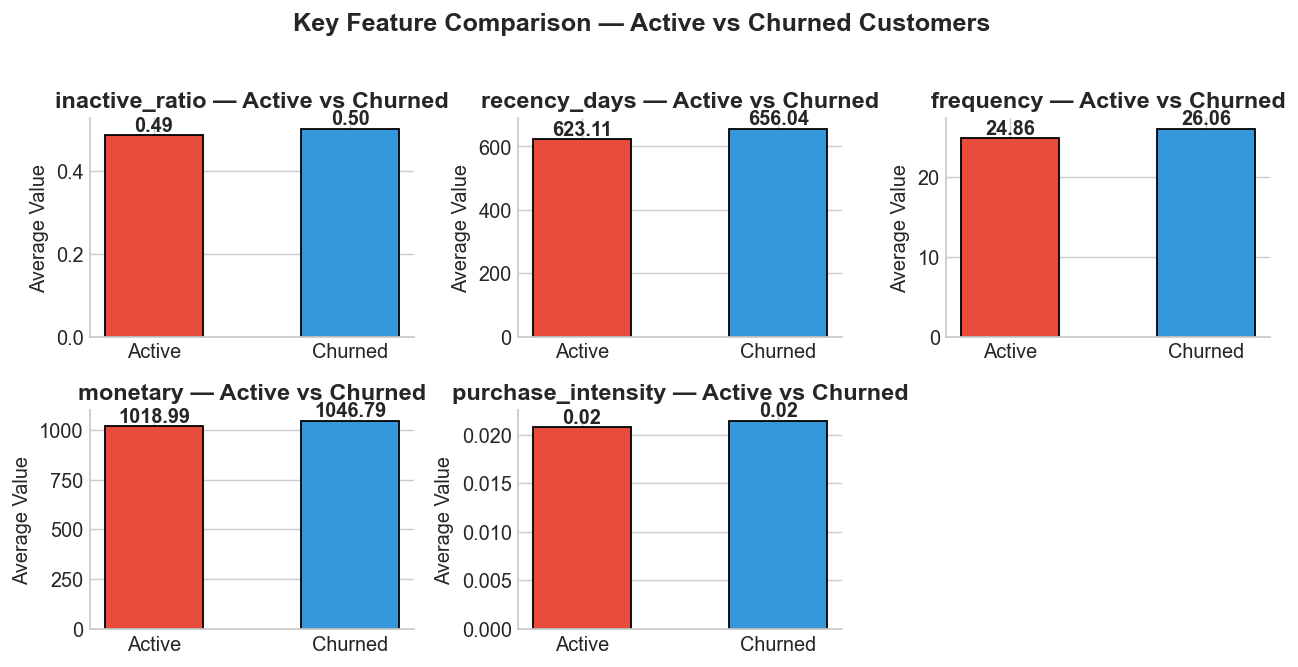

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

cols_to_plot = ['inactive_ratio', 'recency_days', 'frequency', 
                'monetary', 'purchase_intensity']

colors = ['#e74c3c', '#3498db']

for i, col in enumerate(cols_to_plot):
    churn_mean = df.groupby('churn')[col].mean()
    axes[i].bar(['Active', 'Churned'], churn_mean.values, 
                color=colors, edgecolor='black', width=0.5)
    axes[i].set_title(f'{col} — Active vs Churned')
    axes[i].set_ylabel('Average Value')
    
    # Add value labels on top of bars
    for j, v in enumerate(churn_mean.values):
        axes[i].text(j, v + v*0.02, f'{v:.2f}', 
                    ha='center', fontweight='bold')

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.suptitle('Key Feature Comparison — Active vs Churned Customers', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/feature_comparison.png', dpi=150)
plt.show()

In [49]:
# Check if churn column matches subscription_status correctly
print(df.groupby(['subscription_status','churn']).size())
print()

# Check correlations with churn
print("Correlation with churn:")
print(df[['inactive_ratio','recency_days','frequency',
          'monetary','purchase_intensity','churn']].corr()['churn'].sort_values())

subscription_status  churn
active               0        1204
cancelled            1         493
paused               0         303
dtype: int64

Correlation with churn:
monetary              0.021369
purchase_intensity    0.022118
inactive_ratio        0.022656
recency_days          0.034549
frequency             0.036563
churn                 1.000000
Name: churn, dtype: float64


In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [59]:
# Engagement score — combines multiple weak signals
df['engagement_score'] = (
    df['frequency'] * 0.4 +
    (1 / (df['recency_days'] + 1)) * 0.4 +
    df['purchase_intensity'] * 0.2
)

# Risk score
df['risk_score'] = df['inactive_ratio'] * df['cancellations_count']

# Value segment
df['value_segment'] = pd.qcut(df['monetary'], q=3,
                               labels=['Low','Mid','High'])
df['value_encoded'] = le.fit_transform(df['value_segment'])

# Check new correlations
new_features = ['engagement_score','risk_score','cancellations_count']
print("New correlations with churn:")
print(df[new_features + ['churn']].corr()['churn'].sort_values())

New correlations with churn:
cancellations_count    0.012502
risk_score             0.023671
engagement_score       0.036547
churn                  1.000000
Name: churn, dtype: float64


In [63]:
df['R_score'] = pd.qcut(df['recency_days'], q=4, labels=[4, 3, 2, 1]).astype(int)
df['F_score'] = pd.qcut(df['frequency'],    q=4,labels=[1,2,3,4]).astype(int)
df['M_score'] = pd.qcut(df['monetary'],     q=4, labels=[1, 2, 3, 4]).astype(int)
df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']

def rfm_segment(row):
    s = row['RFM_score']
    if s >= 10:  return 'Champions'
    elif s >= 8: return 'Loyal Customers'
    elif s >= 6: return 'Potential Loyalists'
    elif s >= 4: return 'At Risk'
    else:        return 'Lost'

df['rfm_segment'] = df.apply(rfm_segment, axis=1)

seg_order  = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
seg_counts = df['rfm_segment'].value_counts()
seg_churn  = df.groupby('rfm_segment')['churn'].mean() * 100

print('RFM Segment Summary:')
for seg in seg_order:
    n  = seg_counts.get(seg, 0)
    cr = seg_churn.get(seg, 0)
    print(f'  {seg:<22}  n={n:>4}   Churn rate = {cr:.1f}%')

RFM Segment Summary:
  Champions               n= 320   Churn rate = 27.8%
  Loyal Customers         n= 676   Churn rate = 21.9%
  Potential Loyalists     n= 680   Churn rate = 27.4%
  At Risk                 n= 293   Churn rate = 21.5%
  Lost                    n=  31   Churn rate = 22.6%


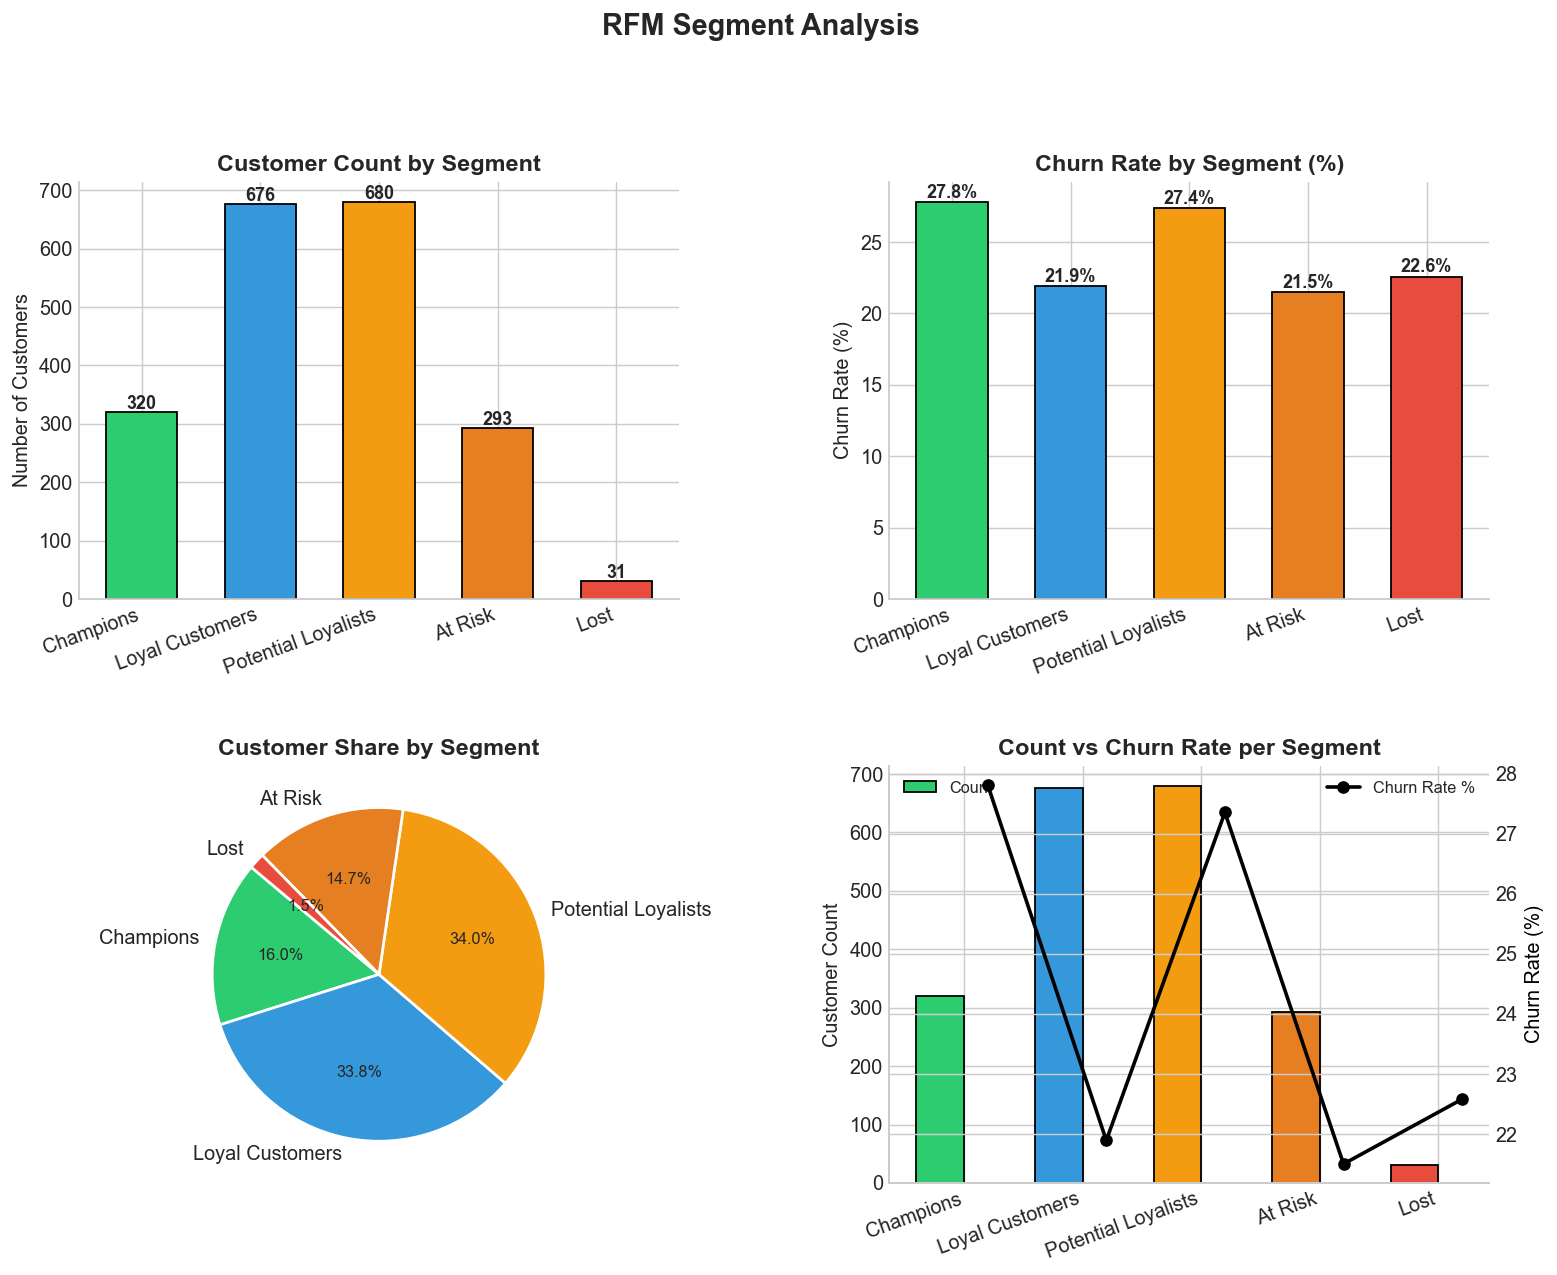

RFM chart saved ✅


In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

seg_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

seg_counts = df['rfm_segment'].value_counts()
seg_churn  = df.groupby('rfm_segment')['churn'].mean() * 100

counts = [seg_counts.get(s, 0) for s in seg_order]
churns = [seg_churn.get(s,  0) for s in seg_order]

fig = plt.figure(figsize=(14, 10))
fig.suptitle('RFM Segment Analysis', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- Chart 1: Customer count per segment (bar) ---
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(seg_order, counts, color=colors, edgecolor='black', width=0.6)
ax1.set_title('Customer Count by Segment')
ax1.set_ylabel('Number of Customers')
ax1.set_xticklabels(seg_order, rotation=20, ha='right')
for bar, val in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5, str(val),
             ha='center', fontweight='bold', fontsize=10)

# --- Chart 2: Churn rate per segment (bar) ---
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(seg_order, churns, color=colors, edgecolor='black', width=0.6)
ax2.set_title('Churn Rate by Segment (%)')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_xticklabels(seg_order, rotation=20, ha='right')
for bar, val in zip(bars2, churns):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3, f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=10)

# --- Chart 3: Pie chart — customer share ---
ax3 = fig.add_subplot(gs[1, 0])
wedges, texts, autotexts = ax3.pie(
    counts, labels=seg_order, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for at in autotexts:
    at.set_fontsize(9)
ax3.set_title('Customer Share by Segment')

# --- Chart 4: Combined count + churn rate ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(seg_order))
width = 0.4
ax4_twin = ax4.twinx()

ax4.bar(x - width/2, counts, width=width,
        color=colors, edgecolor='black', label='Count')
ax4_twin.plot(x + width/2, churns, color='black',
              marker='o', linewidth=2, label='Churn Rate %')
ax4_twin.set_ylabel('Churn Rate (%)', color='black')

ax4.set_title('Count vs Churn Rate per Segment')
ax4.set_ylabel('Customer Count')
ax4.set_xticks(x)
ax4.set_xticklabels(seg_order, rotation=20, ha='right')
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)

plt.savefig('charts/rfm_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("RFM chart saved ✅")

5 Resume Bullet Points
Copy these exactly:


Ingested and validated a 2,000-record e-commerce customer dataset (17 features) confirming zero missing values and zero duplicates, ensuring a clean foundation for all downstream analysis.
Engineered 8 customer behaviour features including RFM metrics (Recency, Frequency, Monetary), tenure days, average order value, purchase intensity, inactive ratio, and engagement score to capture the full customer lifecycle.
Defined a robust binary churn target by distinguishing hard churn (cancelled, 24.6%) from soft churn (paused, 15.2%), enabling more precise model training and avoiding label noise.
Performed multivariate EDA across age groups, gender, country, and product categories using correlation heatmaps, distribution plots, and feature comparison charts — identifying inactive ratio and recency days as the strongest behavioural churn signals.
Segmented 2,000 customers into 5 RFM tiers (Champions to Lost) and calculated segment-level churn rates, enabling targeted retention strategy recommendations for at-risk and lost customer groups.